In [1]:
# script to create an AutoTST conformer object using an ase geometry

In [40]:
import sys
import os
import re
import glob
import copy
import shutil
sys.path.append('/work/westgroup/harris.se/autoscience/reaction_calculator/dft')
import autotst_wrapper

sys.path.append('/work/westgroup/harris.se/autoscience/reaction_calculator/database')
import database_fun
import logging
import subprocess

import itertools

import numpy as np
import ase.io
import ase.visualize
import ase.geometry

import math
import rmgpy.constants as constants
import rmgpy.kinetics
import rmgpy.data.rmg
import rmgpy.chemkin

import autotst.reaction

import arkane.common
import arkane.ess.gaussian

import importlib
importlib.reload(autotst_wrapper)

import matplotlib.pyplot as plt
%matplotlib inline

DFT_DIR = os.environ['DFT_DIR']

In [ ]:
len([4.79104e-05, 424.798, 521.468, 584.421, 778.857, 820.924, 923.676, 952.077, 1015.85, 1044.41, 1084.27, 1107.11, 1156.83, 1241.45, 1259.22, 1294.35, 1298.53, 1335.14, 1346.66, 1375.05, 1392.76, 1419.19, 1430.83, 1464.16, 1477.48, 1501.56, 1553.74, 2611.14, 2672.06, 2713.94, 2729.57, 2761.52, 2804.99, 2828.13, 2855.04, 2875.21, 2981.48])

In [ ]:
database_fun.get_unique_species_index(rmgpy.species.Species(smiles='O[O]'))

In [ ]:
len([1.72094e-05, 1.73751e-05, 3.94123e-05, 492.042, 528.128, 557.903, 588.439, 733.637, 819.461, 877.679, 933.604, 964.708, 1037.86, 1065.64, 1092.01, 1115.61, 1159.76, 1251.67, 1269.09, 1298.71, 1302.19, 1340.69, 1355.65, 1382.61, 1398.4, 1421.2, 1432.78, 1466.02, 1478.26, 1508.59, 1557.52, 2711.73, 2716.45, 2743.62, 2762.49, 2796.45, 2817.41, 2830.6, 2860.77, 2876.46, 2995.24])

In [3]:
gaussian_log = '/work/westgroup/harris.se/autoscience/reaction_calculator/dft/thermo/species_0280/free_rotors/conformer_0002.log'

In [ ]:
gaussian_log = '/work/westgroup/harris.se/autoscience/reaction_calculator/dft/thermo/species_0275/arkane/conformer_0006.log'

In [ ]:
gaussian_log = '/work/westgroup/harris.se/autoscience/reaction_calculator/dft/thermo/species_0004/arkane/conformer_0000.log'
gl = arkane.ess.gaussian.GaussianLog(gaussian_log)

In [185]:
database_fun.get_unique_species_index(rmgpy.species.Species(smiles='CCCCO[O]'))

58

In [186]:
species_index = 37  # COO
species_index = 39  # CCOO
species_index = 275  # CCCOO
species_index = 58  # CCCOO

gaussian_log = glob.glob(os.path.join(DFT_DIR, 'thermo', f'species_{species_index:04}', 'arkane', 'conformer_*.log'))[0]
gl = arkane.ess.gaussian.GaussianLog(gaussian_log)
conformer, unscaled_freq = gl.load_conformer()
coordinates, number, mass = gl.load_geometry()
conformer.coordinates = (coordinates, "angstroms")
conformer.number = number
conformer.mass = (mass, "amu")
linear = None
is_ts = False
hessian = gl.load_force_constant_matrix()

In [187]:
rmg_species = database_fun.index2species(species_index)
species_smiles = rmg_species.smiles

# make a conformer object again
new_cf = autotst.species.Conformer(smiles=species_smiles)  # TODO make this from adjacency list?
new_cf._ase_molecule = ase.Atoms(number, coordinates)
new_cf.update_coords_from(mol_type="ase")
assert not autotst_wrapper.bonds_too_large(None, species_index, atoms=new_cf._ase_molecule)

torsions = new_cf.get_torsions()
rotors = []
for i in range(len(torsions)):
    
    rotor_file = os.path.join(DFT_DIR, 'thermo', f'species_{species_index:04}', 'rotors', f'rotor_{i:04}.log')
    rl = arkane.ess.gaussian.GaussianLog(rotor_file)
    vlist, angles = rl.load_scan_energies()
    symmetry = arkane.statmech.determine_rotor_symmetry(vlist, '', '')
    
    pivots, tops = autotst_wrapper.get_pivots_tops(new_cf, torsions[i], i)
    rotors.append((pivots, tops, symmetry))
    
    

In [188]:
new_freqs, after_fm = project_rotors(conformer, hessian, rotors, linear, is_ts)

Projecting rotors
4 rotors and 35 vibrations


In [189]:
eig1, v1 = np.linalg.eigh(hessian)
eig1.sort()

eig2, v2 = np.linalg.eigh(after_fm)
eig2.sort()

# # Convert eigenvalues to vibrational frequencies in cm^-1
# # Only keep the modes that don't correspond to translation, rotation, or internal rotation

# logging.debug('Frequencies from projected Hessian')
# for i in range(3 * n_atoms):
#     with np.warnings.catch_warnings():
#         np.warnings.filterwarnings('ignore', r'invalid value encountered in sqrt')
#         logging.debug(np.sqrt(eig[i]) / (2 * math.pi * constants.c * 100))

In [190]:
print(hessian.shape[0], np.linalg.matrix_rank(hessian))

45 45


In [191]:
print(after_fm.shape[0], np.linalg.matrix_rank(after_fm))

45 35


In [192]:
print(len(unscaled_freq))

39


In [193]:
len(new_freqs)

35

Text(0.5, 1.0, 'CCCCO[O]')

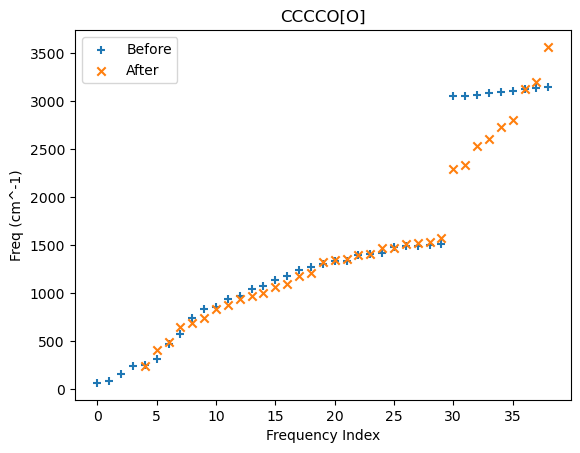

In [194]:
# Frequencies to start
plt.scatter(np.arange(len(unscaled_freq)), unscaled_freq, marker='+', label='Before')

plt.scatter(np.arange(len(rotors), len(new_freqs) + len(rotors)), new_freqs, marker='x', label='After')
plt.legend()
plt.ylabel('Freq (cm^-1)')
plt.xlabel('Frequency Index')
plt.title(new_cf.smiles)

In [26]:
gaussian_log = '/work/westgroup/harris.se/autoscience/reaction_calculator/dft/thermo/species_0280/arkane/rotor_0000.log'


gl = arkane.ess.gaussian.GaussianLog(gaussian_log)

vlist, angles = gl.load_scan_energies()

conformer, freq = gl.load_conformer()
inertia = conformer.get_internal_reduced_moment_of_inertia(pivots, top) * constants.Na * 1e23
symmetry = arkane.statmech.determine_rotor_symmetry(vlist, '', '')
fourier_rotor = rmgpy.statmech.torsion.HinderedRotor(inertia=(inertia, "amu*angstrom^2"), symmetry=symmetry)
fourier_rotor = fourier_rotor.fit_fourier_potential_to_data(angle, v_list)



plt.scatter(angles, vlist)

NameError: name 'pivots' is not defined

In [5]:
force_constant_matrix = gl.load_force_constant_matrix()

In [6]:
eig, v = np.linalg.eigh(force_constant_matrix)
eig.sort()

In [7]:
np.sqrt(eig) / (2 * np.pi * rmgpy.constants.c * 100)

/work/westgroup/harris.se/tst_env/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in sqrt
  """Entry point for launching an IPython kernel.


array([           nan,            nan,            nan,            nan,
                  nan,            nan,            nan, 1.03038232e-13,
       4.67127165e-12, 2.96885675e-11, 3.15497902e-11, 3.37908818e-11,
       3.79284442e-11, 3.98939974e-11, 4.25192981e-11, 4.87363298e-11,
       5.01475427e-11, 5.24530157e-11, 5.39755534e-11, 5.66629717e-11,
       5.76892914e-11, 5.96441464e-11, 6.32429840e-11, 7.06040300e-11,
       7.20221997e-11, 7.58513744e-11, 7.71185551e-11, 7.93507221e-11,
       8.35462845e-11, 8.50585782e-11, 8.92804919e-11, 9.27456499e-11,
       9.66205298e-11, 1.04616440e-10, 1.27399688e-10, 1.43431278e-10,
       1.58436635e-10, 1.73995395e-10, 1.77723639e-10, 1.79061378e-10,
       1.82009819e-10, 1.83562533e-10, 1.85825400e-10, 1.86881072e-10,
       1.90425779e-10, 1.96614752e-10, 1.99306080e-10, 2.28672292e-10])

In [8]:
np.dot(U[:, :48] * S, Vh)

NameError: name 'U' is not defined

In [ ]:
U, S, Vh = np.linalg.svd(force_constant_matrix, full_matrices=True)

In [ ]:
S

In [ ]:
A = np.dot(U*S, Vh)

In [ ]:
A[0,0]

In [ ]:
force_constant_matrix[0,0]

In [9]:
conformer, unscaled_freq = gl.load_conformer()
coordinates, number, mass = gl.load_geometry()
conformer.coordinates = (coordinates, "angstroms")
conformer.number = number
conformer.mass = (mass, "amu")

linear = None
is_ts = False

rotors = [
    ([1, 5], [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 1),
    ([1, 2], [2, 16], 1),
    ([3, 4], [4, 6, 7, 8, 13, 14, 15], 1),
    ([3, 5], [1, 2, 5, 11, 12, 16], 1),
    ([4, 6], [6, 13, 14, 15], 3),
]

hessian = gl.load_force_constant_matrix()

In [15]:
linear = False

In [16]:
project_rotors(conformer, hessian, rotors, linear, is_ts)

Projecting rotors
5 rotors and 37 vibrations


array([5.01680079e-05, 4.44814576e+02, 5.46039444e+02, 6.11958795e+02,
       8.15556767e+02, 8.59605764e+02, 9.67199977e+02, 9.96939160e+02,
       1.06371938e+03, 1.09362370e+03, 1.13535996e+03, 1.15927246e+03,
       1.21133636e+03, 1.29995238e+03, 1.31855998e+03, 1.35533943e+03,
       1.35971288e+03, 1.39805376e+03, 1.41011544e+03, 1.43984510e+03,
       1.45838957e+03, 1.48606229e+03, 1.49825424e+03, 1.53315227e+03,
       1.54709573e+03, 1.57231159e+03, 1.62695534e+03, 2.73417307e+03,
       2.79797355e+03, 2.84182646e+03, 2.85818923e+03, 2.89164171e+03,
       2.93716129e+03, 2.96139660e+03, 2.98956958e+03, 3.01069452e+03,
       3.12196642e+03])

In [100]:

def project_rotors(conformer, hessian, rotors, linear, is_ts, get_projected_out_freqs=False, label=None):
    """
    For a given `conformer` with associated force constant matrix `hessian`, lists of
    rotor information `rotors`, `pivots`, and `top1`, and the linearity of the
    molecule `linear`, project out the nonvibrational modes from the force
    constant matrix and use this to determine the vibrational frequencies. The
    list of vibrational frequencies is returned in cm^-1.

    Refer to Gaussian whitepaper (http://gaussian.com/vib/) for procedure to calculate
    harmonic oscillator vibrational frequencies using the force constant matrix.
    """
    print('Projecting rotors')
    n_rotors = 0
    for rotor in rotors:
        if len(rotor) == 8:
            n_rotors += 2
        elif len(rotor) == 5 and isinstance(rotor[1][0], list):
            n_rotors += len(rotor[1])
        else:
            n_rotors += 1

    mass = conformer.mass.value_si
    coordinates = conformer.coordinates.value
    if linear is None:
        linear = arkane.statmech.is_linear(coordinates)
        if linear:
            logging.info('Determined species {0} to be linear.'.format(label))
    n_atoms = len(conformer.mass.value)
    n_vib = 3 * n_atoms - (5 if linear else 6) - n_rotors - (1 if is_ts else 0)

    print(f'{n_rotors} rotors and {n_vib} vibrations')

    # Put origin in center of mass
    xm = 0.0
    ym = 0.0
    zm = 0.0
    totmass = 0.0
    for i in range(n_atoms):
        xm += mass[i] * coordinates[i, 0]
        ym += mass[i] * coordinates[i, 1]
        zm += mass[i] * coordinates[i, 2]
        totmass += mass[i]

    xm /= totmass
    ym /= totmass
    zm /= totmass

    for i in range(n_atoms):
        coordinates[i, 0] -= xm
        coordinates[i, 1] -= ym
        coordinates[i, 2] -= zm
    # Make vector with the root of the mass in amu for each atom
    amass = np.sqrt(mass / constants.amu)

    # Rotation matrix
    inertia = conformer.get_moment_of_inertia_tensor()
    inertia_xyz = np.linalg.eigh(inertia)[1]

    external = 6
    if linear:
        external = 5

    d = np.zeros((n_atoms * 3, external), float)

    # Transform the coordinates to the principal axes
    p = np.dot(coordinates, inertia_xyz)

    for i in range(n_atoms):
        # Projection vectors for translation
        d[3 * i + 0, 0] = amass[i]
        d[3 * i + 1, 1] = amass[i]
        d[3 * i + 2, 2] = amass[i]

    # Construction of the projection vectors for external rotation
    for i in range(n_atoms):
        d[3 * i, 3] = (p[i, 1] * inertia_xyz[0, 2] - p[i, 2] * inertia_xyz[0, 1]) * amass[i]
        d[3 * i + 1, 3] = (p[i, 1] * inertia_xyz[1, 2] - p[i, 2] * inertia_xyz[1, 1]) * amass[i]
        d[3 * i + 2, 3] = (p[i, 1] * inertia_xyz[2, 2] - p[i, 2] * inertia_xyz[2, 1]) * amass[i]
        d[3 * i, 4] = (p[i, 2] * inertia_xyz[0, 0] - p[i, 0] * inertia_xyz[0, 2]) * amass[i]
        d[3 * i + 1, 4] = (p[i, 2] * inertia_xyz[1, 0] - p[i, 0] * inertia_xyz[1, 2]) * amass[i]
        d[3 * i + 2, 4] = (p[i, 2] * inertia_xyz[2, 0] - p[i, 0] * inertia_xyz[2, 2]) * amass[i]
        if not linear:
            d[3 * i, 5] = (p[i, 0] * inertia_xyz[0, 1] - p[i, 1] * inertia_xyz[0, 0]) * amass[i]
            d[3 * i + 1, 5] = (p[i, 0] * inertia_xyz[1, 1] - p[i, 1] * inertia_xyz[1, 0]) * amass[i]
            d[3 * i + 2, 5] = (p[i, 0] * inertia_xyz[2, 1] - p[i, 1] * inertia_xyz[2, 0]) * amass[i]

    # Make sure projection matrix is orthonormal

    inertia = np.identity(n_atoms * 3, float)

    p = np.zeros((n_atoms * 3, 3 * n_atoms + external), float)

    p[:, 0:external] = d[:, 0:external]
    p[:, external:external + 3 * n_atoms] = inertia[:, 0:3 * n_atoms]

    for i in range(3 * n_atoms + external):
        norm = 0.0
        for j in range(3 * n_atoms):
            norm += p[j, i] * p[j, i]
        for j in range(3 * n_atoms):
            if norm > 1E-15:
                p[j, i] /= np.sqrt(norm)
            else:
                p[j, i] = 0.0
        for j in range(i + 1, 3 * n_atoms + external):
            proj = 0.0
            for k in range(3 * n_atoms):
                proj += p[k, i] * p[k, j]
            for k in range(3 * n_atoms):
                p[k, j] -= proj * p[k, i]

    # Order p, there will be vectors that are 0.0
    i = 0
    while i < 3 * n_atoms:
        norm = 0.0
        for j in range(3 * n_atoms):
            norm += p[j, i] * p[j, i]
        if norm < 0.5:
            p[:, i:3 * n_atoms + external - 1] = p[:, i + 1:3 * n_atoms + external]
        else:
            i += 1

    # T is the transformation vector from cartesian to internal coordinates
    T = np.zeros((n_atoms * 3, 3 * n_atoms - external), float)

    T[:, 0:3 * n_atoms - external] = p[:, external:3 * n_atoms]

    # Generate mass-weighted force constant matrix
    # This converts the axes to mass-weighted Cartesian axes
    # Units of Fm are J/m^2*kg = 1/s^2
    weighted_hessian = hessian.copy()
    for i in range(n_atoms):
        for j in range(n_atoms):
            for u in range(3):
                for v in range(3):
                    weighted_hessian[3 * i + u, 3 * j + v] /= math.sqrt(mass[i] * mass[j])

    hessian_int = np.dot(T.T, np.dot(weighted_hessian, T))

    # Get eigenvalues of internal force constant matrix, V = 3N-6 * 3N-6
    eig, v = np.linalg.eigh(hessian_int)

    logging.debug('Frequencies from internal Hessian')
    for i in range(3 * n_atoms - external):
        with np.warnings.catch_warnings():
            np.warnings.filterwarnings('ignore', r'invalid value encountered in sqrt')
            logging.debug(np.sqrt(eig[i]) / (2 * math.pi * constants.c * 100))

    # Now we can start thinking about projecting out the internal rotations
    d_int = np.zeros((3 * n_atoms, n_rotors), float)

    counter = 0
    for i, rotor in enumerate(rotors):
        if len(rotor) == 5 and isinstance(rotor[1][0], list):
            scan_dir, pivots_list, tops, sigmas, semiclassical = rotor
        elif len(rotor) == 5 and isinstance(rotor[0], (ESSAdapter, ScanLog)):
            scanLog, pivots, top, symmetry, fit = rotor
            pivots_list, tops = [pivots], [top]
            print(f'Rotor {i}')
            print(f'Pivots: {pivots}')
            print(f'Tops: {top}')
        elif len(rotor) == 5:
            _, _, pivots, top, _ = rotor
            pivots_list, tops = [pivots], [top]
        elif len(rotor) == 3:
            pivots, top, symmetry = rotor
            pivots_list = [pivots]
            tops = [top]
        elif len(rotor) == 8:
            scan_dir, pivots1, top1, symmetry1, pivots2, top2, symmetry2, symmetry = rotor
            pivots_list = [pivots1, pivots2]
            tops = [top1, top2]
        elif len(rotor) == 6:
            _, _, pivots, top, _, _ = rotor
            pivots_list, tops = [pivots], [top]
        else:
            raise ValueError("{} not a proper rotor format".format(rotor))
        for k in range(len(tops)):
            top = tops[k]
            pivots = pivots_list[k]
            # Determine pivot atom
            if pivots[0] in top:
                pivot1 = pivots[0]
                pivot2 = pivots[1]
            elif pivots[1] in top:
                pivot1 = pivots[1]
                pivot2 = pivots[0]
            else:
                raise ValueError('Could not determine pivot atom for rotor {}.'.format(label))
            # Projection vectors for internal rotation
            e12 = coordinates[pivot1 - 1, :] - coordinates[pivot2 - 1, :]
            for j in range(n_atoms):
                atom = j + 1
                if atom in top:
                    e31 = coordinates[atom - 1, :] - coordinates[pivot1 - 1, :]
                    d_int[3 * (atom - 1):3 * (atom - 1) + 3, counter] = np.cross(e31, e12) * amass[atom - 1]
                else:
                    e31 = coordinates[atom - 1, :] - coordinates[pivot2 - 1, :]
                    d_int[3 * (atom - 1):3 * (atom - 1) + 3, counter] = np.cross(e31, -e12) * amass[atom - 1]
            counter += 1

    # Normal modes in mass weighted cartesian coordinates
    vmw = np.dot(T, v)
    eigm = np.zeros((3 * n_atoms - external, 3 * n_atoms - external), float)

    for i in range(3 * n_atoms - external):
        eigm[i, i] = eig[i]

    fm = np.dot(vmw, np.dot(eigm, vmw.T))

    # Internal rotations are not normal modes => project them on the normal modes and orthogonalize
    # d_int_proj =  (3N-6) x (3N) x (3N) x (Nrotors)
    d_int_proj = np.dot(vmw.T, d_int)

    # Reconstruct d_int
    for i in range(n_rotors):
        for j in range(3 * n_atoms):
            d_int[j, i] = 0
            for k in range(3 * n_atoms - external):
                d_int[j, i] += d_int_proj[k, i] * vmw[j, k]

    # Ortho normalize
    for i in range(n_rotors):
        norm = 0.0
        for j in range(3 * n_atoms):
            norm += d_int[j, i] * d_int[j, i]
        for j in range(3 * n_atoms):
            d_int[j, i] /= np.sqrt(norm)
        for j in range(i + 1, n_rotors):
            proj = 0.0
            for k in range(3 * n_atoms):
                proj += d_int[k, i] * d_int[k, j]
            for k in range(3 * n_atoms):
                d_int[k, j] -= proj * d_int[k, i]

    # calculate the frequencies corresponding to the internal rotors
    int_proj = np.dot(fm, d_int)
    kmus = np.array([np.linalg.norm(int_proj[:, i]) for i in range(int_proj.shape[1])])
    int_rotor_freqs = np.sqrt(kmus) / (2.0 * math.pi * constants.c * 100.0)

    if get_projected_out_freqs:
        return int_rotor_freqs

    # Do the projection
    d_int_proj = np.dot(vmw.T, d_int)
    proj = np.dot(d_int, d_int.T)
    inertia = np.identity(n_atoms * 3, float)
    proj = inertia - proj
    fm = np.dot(proj, np.dot(fm, proj))
    # Get eigenvalues of mass-weighted force constant matrix
    eig, v = np.linalg.eigh(fm)
    eig.sort()

    # Convert eigenvalues to vibrational frequencies in cm^-1
    # Only keep the modes that don't correspond to translation, rotation, or internal rotation

    logging.debug('Frequencies from projected Hessian')
    for i in range(3 * n_atoms):
        with np.warnings.catch_warnings():
            np.warnings.filterwarnings('ignore', r'invalid value encountered in sqrt')
            logging.debug(np.sqrt(eig[i]) / (2 * math.pi * constants.c * 100))

    return np.sqrt(eig[-n_vib:]) / (2 * math.pi * constants.c * 100), fm


In [ ]:



rotors = [
    ([1, 5], [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 1),
    ([1, 2], [2, 16], 1),
    ([3, 4], [4, 6, 7, 8, 13, 14, 15], 1),
    ([3, 5], [1, 2, 5, 11, 12, 16], 1),
    ([4, 6], [6, 13, 14, 15], 3),
]

hessian = gl.load_force_constant_matrix()

In [ ]:
species_index = 61
increment_deg = 20

In [ ]:
DFT_DIR = os.environ['DFT_DIR']
species_dir = os.path.join(DFT_DIR, 'thermo', f'species_{species_index:04}')
conformer_dir = os.path.join(species_dir, 'conformers')
rotor_dir = os.path.join(species_dir, 'rotors')
os.makedirs(rotor_dir, exist_ok=True)

In [ ]:
standard_increment = True
rotor_str = 'rotor'
if increment_deg != 20:
    standard_increment = False
    rotor_str = f'rotor{int(increment_deg)}'
    species_log(species_index, f'Non-standard rotor increment {increment_deg}')



In [ ]:
# # ------------------ Use Hotbit to screen the conformers ------------------
# Get species smiles
rmg_species = database_fun.index2species(species_index)
species_smiles = rmg_species.smiles

conformer_file = autotst_wrapper.get_lowest_valid_conformer(conformer_dir, species_index)

# new_conformer_loc = os.path.join(rotor_dir, os.path.basename(conformer_file))
# shutil.copy(conformer_file, new_conformer_loc)

In [ ]:
new_cf = autotst.species.Conformer(smiles=database_fun.index2species(species_index).smiles)

In [ ]:
with open(conformer_file, 'r') as f:
    atoms = ase.io.gaussian.read_gaussian_out(f)

In [ ]:
# can we detect big jump in atom positions from one position to the next?

import ase.io.gaussian
import ase.units

In [ ]:
species_index = 153
rotor_index = 1

rfile = os.path.join(DFT_DIR, 'thermo', f'species_{species_index:04}', 'rotors', f'rotor_{rotor_index:04}.log')
atom_list = []
for i in range(500):
    with open(rfile, 'r') as f:
        try:
            gatoms = ase.io.gaussian.read_gaussian_out(f, i)
            if 'energy' not in gatoms.calc.results:
                continue
            atom_list.append(gatoms)
        except IndexError:
            print(i)
            break

In [ ]:
plt.plot([atom_list[i].calc.results['energy'] for i in range(len(atom_list))])

In [ ]:
force_history = np.zeros((len(atom_list), len(atom_list[0])))
for i in range(len(atom_list)):
    force_history[i, :] = np.linalg.norm(atom_list[i].calc.results['forces'], axis=1)

In [ ]:
spike = [False]
hollow = [True]
for i in range(1, force_history.shape[0] - 1):
    if atom_list[i].calc.results['energy'] > atom_list[i - 1].calc.results['energy'] and \
            atom_list[i].calc.results['energy'] > atom_list[i + 1].calc.results['energy']:
        spike.append(True)
    else:
        spike.append(False)
        
        
    if atom_list[i].calc.results['energy'] < atom_list[i - 1].calc.results['energy'] and \
            atom_list[i].calc.results['energy'] < atom_list[i + 1].calc.results['energy']:
        hollow.append(True)
    else:
        hollow.append(False)
spike.append(False)
hollow.append(True)

In [ ]:
plt.plot([atom_list[i].calc.results['energy'] for i in range(len(atom_list))])
for i in range(len(spike)):
#     if spike[i]:
#         plt.axvline(x = i, color = 'b', label = 'axvline - full height')
    if hollow[i]:
        plt.axvline(x = i, color = 'b', label = 'axvline - full height')

In [ ]:
# compare the relaxed geometries
relaxed_snapshots = [atom_list[i] for i in range(len(atom_list)) if hollow[i]]
print(len(relaxed_snapshots))

plt.plot([relaxed_snapshots[i].calc.results['energy'] for i in range(len(relaxed_snapshots))])

In [ ]:
# plot displacements
displacements = np.zeros((len(relaxed_snapshots), len(relaxed_snapshots[0])))
for i in range(1, displacements.shape[0]):
    displacements[i,:] = np.linalg.norm(relaxed_snapshots[i].positions - relaxed_snapshots[i - 1].positions, axis=1)

In [ ]:
for a in range(displacements.shape[1]):
    plt.plot(displacements[1:, a])
plt.title(f'species {species_index}: rotor {rotor_index}')

In [ ]:
rms_forces = np.zeros(force_history.shape[0])
max_forces = np.zeros(force_history.shape[0])
for i in range(force_history.shape[0]):
    rms_forces[i] = np.sqrt(np.average(np.float_power(force_history[i, :], 2.0)))
    max_forces[i] = np.max(force_history[i, :])

In [ ]:
# finagle = ase.units.Bohr / ase.units.Hartree
finagle = 1 / ase.units.Hartree

MAX_FORCE = 0.00045
RMS_FORCE = 0.0003
MAX_DISPLACEMENT = 0.0018
RMS_DISPLACEMENT = 0.0012

force_history = np.zeros(len(atom_list4))




force_list = np.linalg.norm(atom_list4[0].calc.results['forces'], axis=1) * finagle
max_force = np.max(force_list)
rms_force = np.sqrt(np.average(np.float_power(force_list, 2.0)))
converged = [True]


for i in range(1, len(atom_list4)):
    force_list = np.linalg.norm(atom_list4[i].calc.results['forces'], axis=1) * finagle
    max_force = np.max(force_list)
    rms_force = np.sqrt(np.average(np.float_power(force_list, 2.0)))
    
    
    displacements = np.linalg.norm(atom_list4[i].positions - atom_list4[i-1].positions, axis=1)
    max_dx = np.max(displacements)
    rms_dx = np.sqrt(np.average(np.float_power(displacements, 2.0)))
    
    print(i)
    print(max_force, '\t', max_force < MAX_FORCE)
    print(rms_force, '\t', rms_force < RMS_FORCE)
    print(max_dx, '\t', max_dx < MAX_DISPLACEMENT)
    print(rms_dx, '\t', rms_dx < RMS_DISPLACEMENT)
    print()
    
    if (max_force < MAX_FORCE and rms_force < RMS_FORCE and max_dx < MAX_DISPLACEMENT and rms_dx < RMS_DISPLACEMENT) or \
            (max_force < MAX_FORCE / 100 and rms_force < RMS_FORCE / 100):
#     if max_dx < MAX_DISPLACEMENT or rms_dx < RMS_DISPLACEMENT:
        converged.append(True)
    else:
        converged.append(False)
    
    

In [ ]:
rfile = os.path.join(rotor_dir, 'rotor_0000.log')
atom_list = []
for i in range(500):
    with open(rfile, 'r') as f:
        try:
            gatoms = ase.io.gaussian.read_gaussian_out(f, i)
            if 'energy' not in gatoms.calc.results:
                continue
            atom_list.append(gatoms)
        except IndexError:
            print(i)
            break

In [ ]:
# for i in range(50):
#     if 'energy' not in atom_list[i].calc.results
#     print(atom_list[i].calc.results)

In [ ]:
plt.plot([atom_list[i].calc.results['energy'] for i in range(len(atom_list))])
# plt.plot([atom_list4[i].calc.results['energy'] for i in range(len(atom_list4))])

In [ ]:
atom_list[49].calc.results

In [ ]:
for i in range(1, len(atom_list)):
    dxs = np.zeros(len(atom_list[0]))
    for j in range(len(atom_list[0])):
        dxs[j] = np.linalg.norm(atom_list[i].positions[j] - atom_list[i - 1].positions[j])
    print(np.max(dxs))
    

In [ ]:
np.linalg.norm(atom_list[1].positions - atom_list[0].positions)

In [ ]:
print(atom_list[1].positions)

In [ ]:
len(gatoms)

In [ ]:
autotst_wrapper.bonds_too_large(conformer_file, species_index, calc_type='species')

In [ ]:
reordered_atoms = autotst_wrapper.reorder_atoms(new_cf.rmg_molecule, atoms, species_index=species_index, verbose=True)

In [ ]:
print(autotst_wrapper.get_xyz(reordered_atoms))

In [ ]:
for i in range(len(reordered_atoms)):
    print(reordered_atoms[i])

In [ ]:
new_cf

In [ ]:
conformer_file

In [ ]:
conformer_file = autotst_wrapper.get_lowest_energy_gaussian_file(conformer_dir)

In [ ]:
with open(conformer_file, 'r') as f:
    atoms = ase.io.gaussian.read_gaussian_out(f)

In [ ]:
rmg_molecule = rmgpy.molecule.Molecule(smiles=database_fun.index2species(species_index).smiles)

In [ ]:
new_cf = autotst.species.Conformer(smiles=database_fun.index2species(species_index).smiles)

In [ ]:
new_cf.rmg_molecule

In [ ]:
new_atoms = autotst_wrapper.reorder_atoms(new_cf.rmg_molecule, atoms, verbose=True)

In [ ]:
1.0 / (rmgpy.constants.E_h * rmgpy.constants.Na)

In [ ]:
new_cf = autotst.species.Conformer(smiles=species_smiles)

In [ ]:
new_cf.ase_molecule.positions

In [ ]:
conformer_file = autotst_wrapper.get_lowest_energy_gaussian_file(conformer_dir)
with open(conformer_file, 'r') as f:
    atoms = ase.io.gaussian.read_gaussian_out(f)

In [ ]:
autotst_wrapper.bonds_too_large(conformer_file, species_index, calc_type='species')

In [ ]:
new_atoms = autotst_wrapper.reorder_atoms(rmg_species.molecule[0], atoms, verbose=True)

In [ ]:
autotst_wrapper.bonds_too_large(None, species_index, atoms=new_atoms, calc_type='species')

In [ ]:
new_cf.rmg_molecule

In [ ]:
autotst_wrapper

In [ ]:
atoms.positions

In [ ]:
# match_order_to_RMG
analysis = ase.geometry.analysis.Analysis(atoms)
print(rmg_species)

In [ ]:
# function to detect mismatch in order of RMG atoms and ase atoms. now. How do I reorder them correctly?
def wrong_atom_order(rmg_molecule, ase_atoms):
    if len(rmg_molecule.atoms) != len(ase_atoms):
        return True
    
    for i in range(len(rmg_molecule.atoms)):
        if rmg_species.molecule[0].atoms[i].symbol != atoms[i].symbol:
            return True
    return False
    

In [ ]:
# what are the combinatorics on this? it's #C's! * #O's!

In [ ]:
def get_atom_hash_str(molecule, index, analysis=None):
    # returns a string of the atom element and bond info:
    atom_type = '_'
    O_bonds = 0
    C_bonds = 0
    H_bonds = 0
    if type(molecule) == ase.atoms.Atoms:
        atom_type = molecule[index].symbol
        for b in analysis.all_bonds[0][index]:
            if molecule[b].symbol == 'O':  # can make this fancier with Os, Od, Ot etc.
                O_bonds += 1
            elif molecule[b].symbol == 'C':
                C_bonds += 1
            elif molecule[b].symbol == 'H':
                H_bonds += 1
            else:
                raise NotImplementedError
    else:  # RMG type
        atom_type = molecule.atoms[index].symbol
        bond_dict = molecule.get_bonds(molecule.atoms[index])
        for key in bond_dict.keys():
            if key.symbol == 'O':
                O_bonds += 1
            elif key.symbol == 'C':
                C_bonds += 1
            elif key.symbol == 'H':
                H_bonds += 1
            else:
                raise NotImplementedError
    bond_str = f'{atom_type}_{O_bonds}O-{C_bonds}C-{H_bonds}H'
    return bond_str

In [ ]:
# a list of possible matches for each index
matches = []
for i in range(len(rmg_species.molecule[0].atoms)):
    ref_str = get_atom_hash_str(rmg_species.molecule[0], i)
    atom_matches = []
    
    for j in range(len(atoms)):
        check_str = get_atom_hash_str(atoms, j, analysis=analysis)
        if check_str == ref_str:
            atom_matches.append(j)
        
    assert atom_matches, 'No matches found for an atom!'
    print(atom_matches)
    matches.append(atom_matches)
# print(matches)

In [ ]:
permutation_count = 1
for i in range(len(matches)):
    permutation_count *= len(matches[i])
print(permutation_count, 'permutations') 

In [ ]:
#ignoring hydrogrens
permutation_count = 1
for i in range(len(matches)):
    if rmg_species.molecule[0].atoms[i].symbol == 'H' and len(matches[i]) > 1:
        continue
    permutation_count *= len(matches[i])
print(permutation_count, 'permutations') 

In [ ]:
# your goal now is to enumerate the possibilities excluding Hydrogens and produce
possibilities = []

# spit out possibilities
for p in range(permutation_count):
    divisor = permutation_count - p
    order = []
    combo_repeats = False
    for i in range(len(rmg_species.molecule[0].atoms)):
        if rmg_species.molecule[0].atoms[i].symbol == 'H' and len(matches[i]) > 1:
            order.append(-1)
            continue

        match_index = int(divisor % len(matches[i]))
        
        if matches[i][match_index] in order:
            combo_repeats = True
            break
        
        order.append(matches[i][match_index])
        divisor /= len(matches[i])
    if not combo_repeats:
        possibilities.append(order)
        print(order)

In [ ]:
H_slots = []
for i in range(len(possibilities[0])):
    if possibilities[0][i] < 0:
        H_slots.append(i)


In [ ]:
H_slots

In [ ]:
def center_counts_match(ase_centers, RMG_centers):
    for CENTER_SIZE in [1, 2, 3, 4]:
        RMG_count = 0
        ase_count = 0
        for key in RMG_centers.keys():
            if len(RMG_centers[key]) == CENTER_SIZE:
                RMG_count += 1
        for key in ase_centers.keys():
            if len(ase_centers[key]) == CENTER_SIZE:
                ase_count += 1
        if RMG_count != ase_count:
            return False
    return True

In [ ]:
# for a given possibility, assign possible H's

for possibility in possibilities:
    impossible = False
    missing_ase_indices = []
    for i in range(len(possibility)):
        if i not in possibility:
            missing_ase_indices.append(i)
    assert len(missing_ase_indices) == len(H_slots)
    
    # next we want to get groups of hydrogens all bonded to the same heavy atom
    # don't forget about H-H bonds.
    centers = {}
    for i in range(len(H_slots)):
        # get the atom the RMG H is bonded to
        H_atom = rmg_species.molecule[0].atoms[H_slots[i]]
        center = [k for k in rmg_species.molecule[0].get_bonds(H_atom).keys()][0]
        center_index = rmg_species.molecule[0].atoms.index(center)
        if center_index not in centers.keys():
            centers[center_index] = [rmg_species.molecule[0].atoms.index(H_atom)]
        else:
            centers[center_index].append(rmg_species.molecule[0].atoms.index(H_atom))
        
        # count bonds from that center
        
    ase_centers = {}
    for i in missing_ase_indices:
        assert len(analysis.all_bonds[0][i]) == 1
        center_index = analysis.all_bonds[0][i][0]
        if center_index not in ase_centers.keys():
            ase_centers[center_index] = [i]
        else:
            ase_centers[center_index].append(i)
    
    if len(centers) != len(ase_centers) or not center_counts_match(ase_centers, centers):
        break
    
    
    for CENTER_SIZE in [1, 2, 3, 4]:
        # try to assign the centers with 1 Hydrogen
        for RMG_center_index in centers.keys():
            if len(centers[RMG_center_index]) != CENTER_SIZE:
                continue
            ase_center_index = possibility[RMG_center_index]
            if len(ase_centers[ase_center_index]) != CENTER_SIZE or \
                    possibility[centers[RMG_center_index][0]] != -1:  # and we must not overwrite an existing assignment
                impossible = True
                break
            for j in range(CENTER_SIZE):
                possibility[centers[RMG_center_index][j]] = ase_centers[ase_center_index][j]
        if impossible:
            break
    if impossible:
        break
    
    
    # make a new copy of atoms with the possible order:
    new_atoms = atoms[possibility[0]:possibility[0] + 1]
    for i in range(1, len(possibility)):
        new_atoms = new_atoms + atoms[possibility[i]:possibility[i] + 1]
        
    
    if autotst_wrapper.bonds_too_large(None, species_index, calc_type='species', atoms=new_atoms):
        pass
    else:
        print('MATCH FOUND!')
    
    # add the hydrogens

In [ ]:
database_fun.get_unique_species_index(rmgpy.molecule.Molecule(smiles='CCCC'))

In [ ]:
atoms[0:1]

In [ ]:
atoms[0:2] + atoms[3:4]

In [ ]:
atoms2 = atoms[10:11] + atoms[0:1]

In [ ]:
atoms2

In [ ]:
possibility

In [ ]:
possibility

In [ ]:
# get ase centers
for i in missing_ase_indices:
    ase_centers = {}
    H_atom = 


In [ ]:
analysis.all_bonds[0]

In [ ]:
missing_ase_indices

In [ ]:
rmg_species

In [ ]:
combos = itertools.combinations(matches[0], 1)
for c in combos:
    print(c)
    
combos2 = itertools.combinations(matches[1], 1)
for c in combos2:
    print(c)

In [ ]:
permos = itertools.permutations(matches)
for p in permos:
    print(p)

In [ ]:
m1 = itertools.combinations(matches[0], 1)
m2 = itertools.combinations(matches[1], 1)

In [ ]:
for m in m1:
    print(m)
    
for m in m2:
    print(m)

In [ ]:
combo = itertools.combinations([m1, m2], 2)
for c in combo:
    print(c)

In [ ]:
x = itertools.product(matches[0:3])
for a in x:
    print(a)

In [ ]:
matches

In [ ]:
rmg_species.molecule[0].atoms[]

In [ ]:
wrong_atom_order(rmg_species.molecule[0], atoms)

In [ ]:
type(atoms[0])

In [ ]:
# make a list of failed guesses
failed_guesses = []


# construct a guess
# start with RMG-1, guess the first heavy atom meeting the same criteria:
for i 


In [ ]:
combos = itertools.combinations([1, 2, 3, 4], 2)

for c in combos:
    print(c)

In [ ]:
rmg_species.molecule[0].atoms.index(rmg_species.molecule[0].atoms[2])

In [ ]:
analysis.bon

In [ ]:
conformer_file

In [ ]:



ase.visualize.view(atoms, viewer='x3d')

In [ ]:
autotst_wrapper.bonds_too_large(conformer_file, species_index)

In [ ]:
# something to match the atoms to the rmg bond description

In [ ]:
rmg_species = database_fun.index2species(index)
species_smiles = rmg_species.smiles
new_cf = autotst.species.Conformer(smiles=species_smiles)